Preview of data:


,biden,female,age,educ,dem,rep
0,90,0,19,12,1,0
1,70,1,51,14,1,0
2,60,0,27,14,0,0
3,50,1,43,14,1,0
4,60,1,38,14,0,1



Test Mean Squared Error (MSE): 396.19


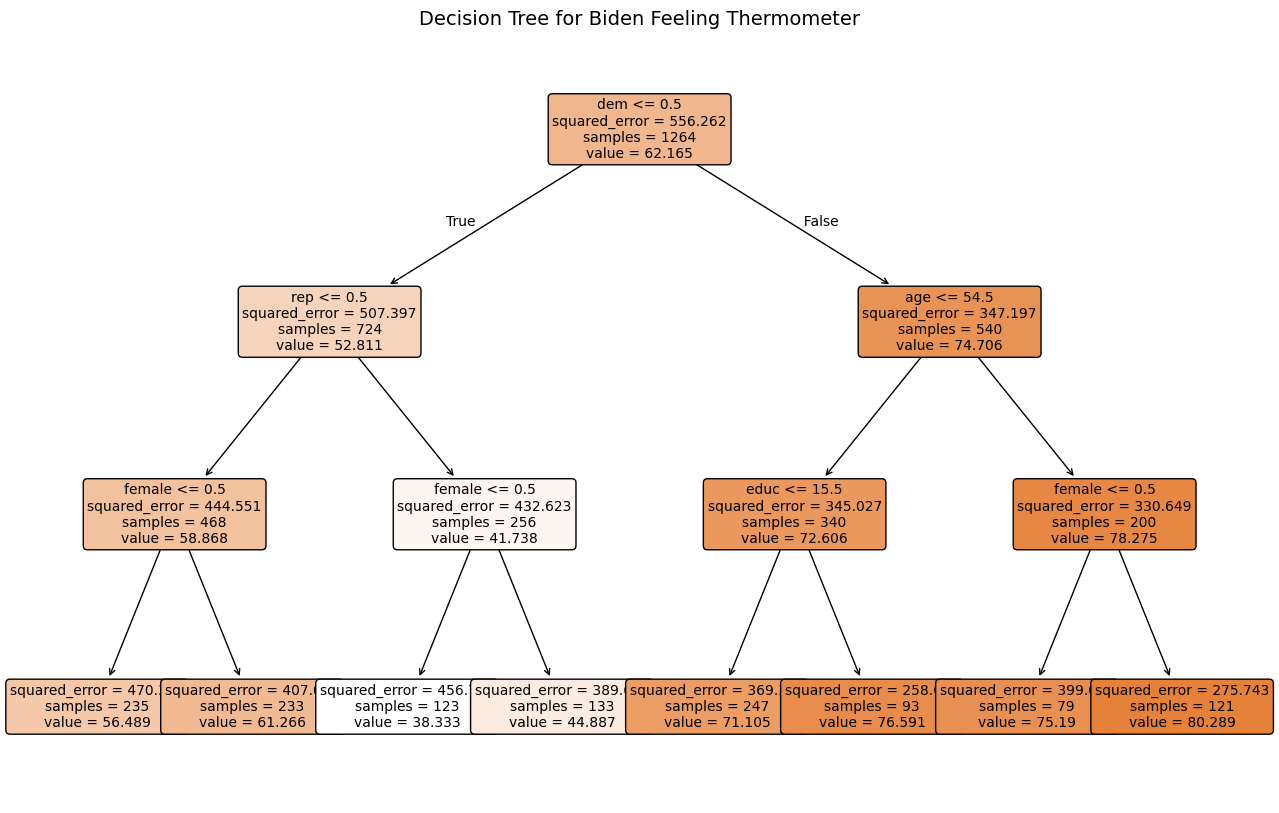


Feature Importances:
dem       0.707531
rep       0.231687
female    0.031767
age       0.019312
educ      0.009703
dtype: float64


In [ ]:
## PS7 Regression Trees

# --- Tas 1 ---

%matplotlib inline

# --- Imports ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# --- Load data ---
file_path = r"C:\Users\David Munson\Desktop\git\CompEcon_Fall25\Problemsets\biden.csv"
biden = pd.read_csv(file_path)

# Display first few rows
print("Preview of data:")
display(biden.head())

# --- Define predictors and response ---
X = biden[['female', 'age', 'educ', 'dem', 'rep']]
y = biden['biden']

# --- Split data ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=25
)

# --- Fit Decision Tree ---
tree_model = DecisionTreeRegressor(
    max_depth=3, 
    min_samples_leaf=5, 
    random_state=25
)
tree_model.fit(X_train, y_train)

# --- Predict on test data ---
y_pred = tree_model.predict(X_test)

# --- Compute test MSE ---
mse = mean_squared_error(y_test, y_pred)
print(f"\nTest Mean Squared Error (MSE): {mse:.2f}")

# --- Plot the decision tree ---
plt.figure(figsize=(16, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for Biden Feeling Thermometer", fontsize=14)
plt.show()

# --- Show feature importance ---
importances = pd.Series(tree_model.feature_importances_, index=X.columns)
print("\nFeature Importances:")
print(importances.sort_values(ascending=False))

# Task 1:

The decision tree shows that party affiliation is the strongest predictor of attitudes toward Joe Biden. The first split occurs on whether the respondent is a Democrat who report much higher Biden feeling thermometer scores (average around 75) than non-Democrats (around 62). For non-Democrats, the next important distinction is whether the respondent is Republican; Republicans have noticeably lower average scores (around 52) than independents. Gender and education also play smaller roles—within some groups, women and more educated individuals tend to rate Biden slightly higher. Overall, the model suggests political identity is the primary factor shaping attitudes toward Biden, while age, gender, and education provide secondary refinements. Test Mean Squared Error (MSE): 396.19

In [8]:
# --- Task 2: RandomizedSearchCV for Decision Tree Regression ---

from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import randint as sp_randint
from sklearn.metrics import mean_squared_error

# Define parameter distributions to sample from
param_dist = {
    "max_depth": sp_randint(3, 10),
    "min_samples_split": sp_randint(2, 20),
    "min_samples_leaf": sp_randint(2, 20)
}

# Base model
tree = DecisionTreeRegressor(random_state=25)

# Set up randomized search (100 random combinations, 5-fold CV)
rand_search = RandomizedSearchCV(
    estimator=tree,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    random_state=25
)

# Fit randomized search on the full dataset
rand_search.fit(X, y)

# Extract results
best_params = rand_search.best_params_
best_cv_mse = -rand_search.best_score_  # convert from negative MSE to positive

# Fit new model using best parameters
best_tree = DecisionTreeRegressor(**best_params, random_state=25)
best_tree.fit(X_train, y_train)
y_pred_best = best_tree.predict(X_test)
test_mse_best = mean_squared_error(y_test, y_pred_best)

# --- Print results ---
print("Best Hyperparameters Found:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"\nCross-Validated MSE of Best Model: {best_cv_mse:.2f}")
print(f"Test MSE of Best Model: {test_mse_best:.2f}")

importances_tree = pd.Series(best_tree.feature_importances_, index=X.columns)
print("\nFeature Importances (Decision Tree):")
print(importances_tree.sort_values(ascending=False))


Best Hyperparameters Found:
  max_depth: 3
  min_samples_leaf: 18
  min_samples_split: 5

Cross-Validated MSE of Best Model: 401.71
Test MSE of Best Model: 396.19

Feature Importances (Decision Tree):
dem       0.707531
rep       0.231687
female    0.031767
age       0.019312
educ      0.009703
dtype: float64


# Task 2:

The optimal parameters found were max_depth = 3, min_samples_split = 5, and min_samples_leaf = 18. The cross-validated MSE was 401.71, and the test MSE was 396.19. These values are very close, suggesting the model generalizes well but that tuning did not noticeably improve performance, meaning the original tree was already close to optimal for this dataset.

In [7]:
# --- Task 3: RandomizedSearchCV for Random Forest Regression ---

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
from sklearn.metrics import mean_squared_error

# Define parameter distributions for Random Forest
param_dist = {
    "n_estimators": sp_randint(10, 200),
    "max_depth": sp_randint(3, 10),
    "min_samples_split": sp_randint(2, 20),
    "min_samples_leaf": sp_randint(2, 20),
    "max_features": sp_randint(1, 5)
}

# Initialize Random Forest model
rf = RandomForestRegressor(random_state=25)

# Set up randomized search (100 random combinations, 5-fold CV)
rand_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    random_state=25
)

# Fit on the full dataset (for hyperparameter tuning)
rand_search_rf.fit(X, y)

# Extract results
best_params_rf = rand_search_rf.best_params_
best_cv_mse_rf = -rand_search_rf.best_score_

# Fit new Random Forest model using best parameters
best_rf = RandomForestRegressor(**best_params_rf, random_state=25)
best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)
test_mse_rf = mean_squared_error(y_test, y_pred_rf)

# --- Print results ---
print("Best Hyperparameters Found (Random Forest):")
for param, value in best_params_rf.items():
    print(f"  {param}: {value}")

print(f"\nCross-Validated MSE of Best RF Model: {best_cv_mse_rf:.2f}")
print(f"Test MSE of Best RF Model: {test_mse_rf:.2f}")

importances_rf = pd.Series(best_rf.feature_importances_, index=X.columns)
print("\nFeature Importances (Random Forest):")
print(importances_rf.sort_values(ascending=False))


Best Hyperparameters Found (Random Forest):
  max_depth: 3
  max_features: 3
  min_samples_leaf: 6
  min_samples_split: 16
  n_estimators: 146

Cross-Validated MSE of Best RF Model: 397.60
Test MSE of Best RF Model: 391.68

Feature Importances (Random Forest):
dem       0.501644
rep       0.403988
age       0.049265
female    0.026633
educ      0.018469
dtype: float64


The random forest model performed similarly to the single tree. The best parameters were max_depth = 3, min_samples_split = 16, min_samples_leaf = 6, max_features = 3, and n_estimators = 146. The cross-validated MSE was 397.60, and the test MSE was 391.68. These results show only a small improvement compared to the decision tree, suggesting that adding more trees did not greatly reduce prediction error for this dataset.